In [1]:
import gymnasium as gym
from gymnasium_env import BlokusEnv
from src.agents.agent import Agent

/Users/mario/Documents/proj/cam/Blokus/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment gymnasium_env/Blokus-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [2]:
class SingleAgentBlokusEnv(BlokusEnv):
    AGENT_INDEX = 2
    def __init__(self, hidden_agent_policy = "random",  *args, **kwargs, ):
        super(SingleAgentBlokusEnv, self).__init__(*args, **kwargs)
        self.agent = Agent("random hidden", policy=hidden_agent_policy)
        
    def step(self, action):
        assert self.current_player == 1
        # assert False # check this!!! There is a bug here

        obs, total_reward, terminated, truncated, info = super(SingleAgentBlokusEnv, self).step(action)
        if terminated or truncated: 
            return obs, total_reward, terminated, truncated, info
        
        while self.current_player == self.AGENT_INDEX:
            actions = self.possible_actions(self.AGENT_INDEX) # get possible actions for the random agent
            assert len(actions) > 0
            action = self.agent.get_action(actions)
            obs, reward, terminated, truncated, info = super(SingleAgentBlokusEnv, self).step(action)
            total_reward -= reward
            assert not truncated
            if terminated:
                return obs, total_reward, terminated, truncated, info
        
        return obs, total_reward, terminated, truncated, info

    def reset(self, *args, **kwargs):
        return super(SingleAgentBlokusEnv, self).reset(*args, **kwargs)

# Create an instance of the custom environment

In [3]:
env = SingleAgentBlokusEnv(board_size=7, num_players=2, render_mode="console", render_scale=10, neighborhood_dir="/Users/mario/Documents/proj/cam/Blokus/gymnasium_env/envs/auxiliary/pre_neighbors", mode = "good")

Neighborhood to encoded actions loaded
Initialised on good mode


In [ ]:
import numpy as np
from tqdm import tqdm
import pickle
import cProfile

q_table = {}

try:
    with open('q_table.pkl', 'rb') as f:
        q_table = pickle.load(f)
except FileNotFoundError:
    q_table = {}
    
def encode_board(board: np.ndarray) -> str:
    return ''.join(map(str, board.flatten()))

def decode_board(encoded_board : str, n: int) -> np.ndarray:
    board = []
    board = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            board[i, j] = int(encoded_board[i * n + j])
    return board

def create_q_table(state: str, actions: np.ndarray):
    if state not in q_table:
        q_table[state] = {action: 0 for action in actions}
    

def get_q_value(state: str, action: int) -> float:
    return q_table[state][action]

def set_q_value(state: str, action: int, value: float):
    q_table[state][action] = value

def argmax(state: str) -> int:
    return max(q_table[state], key=q_table[state].get)

def maxi(state: str) -> float:
    if len(q_table[state].values()) == 0:
        return 0
    return max(q_table[state].values())


def main():
    agent = Agent(name = "Mario", policy="random")
    # Initialize Q-table
    env.render_mode = "console"

    # Hyperparameters
    alpha = 0.1  # Learning rate
    gamma = 0.995  # Discount factor
    epsilon = 1.0  # Exploration rate
    epsilon_decay = 0.99
    min_epsilon = 0.01
    num_episodes = 250000

    win_counter, tie_counter, lose_counter = 0, 0, 0

    # Q-learning algorithm
    pbar = tqdm(range(num_episodes))
    win_rate = []
    tie_rate = []
    loss_rate = []

    for i in pbar:
        # pbar.set_description(f"Episode {i+1}: Wins: {win_counter}, Ties: {tie_counter}, Losses: {lose_counter}, Epsilon: {epsilon:.4f}")
        obs, info = env.reset()
        state = encode_board(obs["state"])
        done = False
        create_q_table(state, obs["possible_actions"])
        total_reward = 0
        while not done:
            if np.random.uniform(0, 1) < epsilon:
                action = agent.get_action(obs["possible_actions"]) # Explore action space
                # print(obs["possible_actions"])
            else:
                action = argmax(state)  # Exploit learned values

            # print(action, state, obs["possible_actions"])
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = encode_board(next_obs["state"])
            obs = next_obs
            # Update Q-table
            create_q_table(next_state, next_obs["possible_actions"])
            total_reward += reward
            if done:
                if total_reward > 0:
                    reward1 = reward + 10
                elif total_reward == 0:
                    reward1 = reward - 10
                else:
                    reward1 = reward - 20
            else:
                reward1 = reward
            set_q_value(state, action, get_q_value(state, action) + alpha * (reward1 + gamma * (1 - done) * maxi(next_state) - get_q_value(state, action)))
            # q_table[state, action] = q_table[state, action] + alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])
            done = terminated or truncated
            state = next_state
            if terminated:
                if total_reward > 0:
                    win_counter += 1
                elif total_reward == 0:
                    tie_counter += 1
                else:
                    lose_counter += 1
                
            if truncated:
                print("Truncated")
                assert False
        if (i + 1) % 100 == 0:
            pbar.set_description(f"E {i+1}: W: {win_counter}, T: {tie_counter}, L: {lose_counter}, ε: {epsilon:.4f}, S: {len(q_table)}")
            win_counter = 0
            tie_counter = 0
            lose_counter = 0
        if i < num_episodes - 100 + 1:
            epsilon = max(min_epsilon, epsilon * epsilon_decay)
        else:
            epsilon = 0
        
    # with open('q_table1.pkl', 'wb') as f:
    #     pickle.dump(q_table, f)
    # print("Q-table saved")

# cProfile.run("main()", sort=  "cumtime")

In [5]:
import random

q_table = {}
def encode_board(board: np.ndarray) -> str:
    return ''.join(map(str, board.flatten()))

def decode_board(encoded_board : str, n: int) -> np.ndarray:
    board = []
    board = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            board[i, j] = int(encoded_board[i * n + j])
    return board

def create_q_table(state: str, actions: np.ndarray):
    if state not in q_table:
        q_table[state] = {action: 0 for action in actions}
    

def get_q_value(state: str, action: int) -> float:
    return q_table[state][action]

def set_q_value(state: str, action: int, value: float):
    q_table[state][action] = value

not_visited = 0
def argmax(state: str) -> int:
    if not state in q_table:
        global not_visited
        not_visited += 1
        return -1
    return max(q_table[state], key=q_table[state].get)

def maxi(state: str) -> float:
    if len(q_table[state].values()) == 0:
        return 0
    return max(q_table[state].values())

# env.render_mode = "human"
env.render_mode = "console"
with open('q_table1.pkl', 'rb') as f:
    q_table = pickle.load(f)
def test_agent(env, num_episodes=100):
    global q_table
    win_counter, tie_counter, lose_counter = 0, 0, 0
    for _ in range(num_episodes):
        obs, info = env.reset()
        state = encode_board(obs["state"])
        done = False
        total_reward = 0

        while not done:
            action = argmax(state)  # Use the trained agent's policy
            if action == -1:
                action = random.choice(obs["possible_actions"])
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = encode_board(next_obs["state"])
            state = next_state
            obs = next_obs
            total_reward += reward
            done = terminated or truncated
            # env.render()
        if total_reward > 0:
            win_counter += 1
        elif total_reward == 0:
            tie_counter += 1
        else:
            lose_counter += 1

    return win_counter, tie_counter, lose_counter

win_counter1 = np.zeros(1000)
tie_counter1 = np.zeros(1000)
lose_counter1 = np.zeros(1000)
# Test the agent
for i in tqdm(range(1000)):
    win_counter1[i], tie_counter1[i], lose_counter1[i] = test_agent(env)


print(f"Number of not visited states: {not_visited}")

100%|██████████| 1000/1000 [01:03<00:00, 15.78it/s]

Number of not visited states: 27588


Number of win_counter less than 75: 1


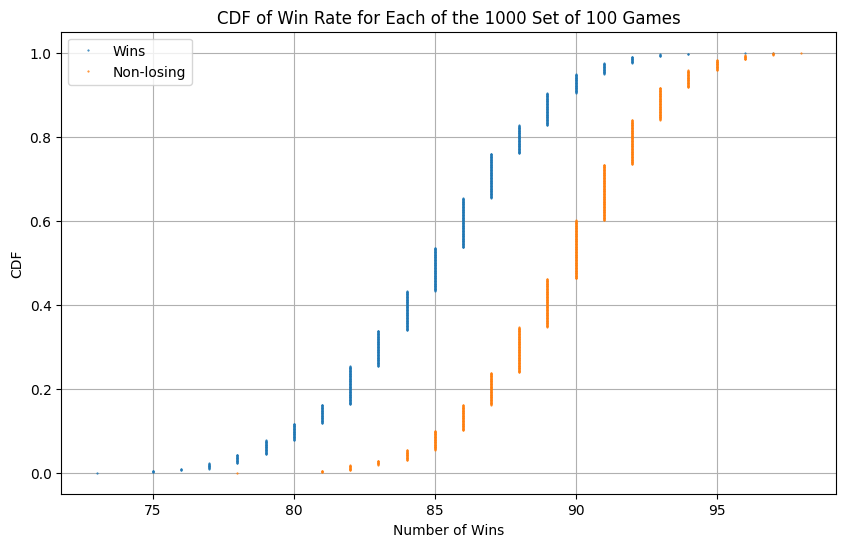

In [6]:
import matplotlib.pyplot as plt

win_counter = win_counter1
tie_counter = tie_counter1
lose_counter = lose_counter1
non_losing_counter = win_counter + tie_counter
# Calculate the CDF
win_counter_sorted = np.sort(win_counter)
cdf = np.arange(1, len(win_counter_sorted) + 1) / len(win_counter_sorted)

# Plot the CDF for wins
plt.figure(figsize=(10, 6))
plt.plot(win_counter_sorted, cdf, marker='.', linestyle='none', label='Wins', markersize=1)
plt.xlabel('Number of Wins')
plt.ylabel('CDF')
plt.title('CDF of Win Rate for Each of the 1000 Set of 100 Games')
plt.grid(True)

num_wins_less_than_75 = np.sum(win_counter < 75)
print(f"Number of win_counter less than 75: {num_wins_less_than_75}")

# Calculate and plot the CDF for non-losing counter
non_losing_counter_sorted = np.sort(non_losing_counter)
cdf_non_losing = np.arange(1, len(non_losing_counter_sorted) + 1) / len(non_losing_counter_sorted)
plt.plot(non_losing_counter_sorted, cdf_non_losing, marker='.', linestyle='none', label='Non-losing', markersize=1)

plt.legend()
plt.show()

In [7]:
print(sum(win_counter),sum(non_losing_counter))

84943.0 89550.0
